# Data Cleaning & Feature Engineering
## Notebook 02: Preparing Air Quality Data for Modeling

### Objective
This notebook focuses on transforming raw air quality data into a structured,
model-ready format suitable for time-series forecasting, spatial analysis,
and public health risk modeling.

### Design Philosophy
- Preserve real-world irregularities
- Avoid aggressive data removal
- Treat missingness as a potential signal

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
DATA_PATH = "../data/raw/rows.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,index,MeasureId,MeasureName,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly
0,0,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1051,Elmore,1999,5.0,No Units,No Units,Monitor Only,1
1,1,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1073,Jefferson,1999,39.0,No Units,No Units,Monitor Only,1
2,2,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1079,Lawrence,1999,28.0,No Units,No Units,Monitor Only,1
3,3,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1089,Madison,1999,31.0,No Units,No Units,Monitor Only,1
4,4,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1097,Mobile,1999,32.0,No Units,No Units,Monitor Only,1


In [60]:
columns_to_keep = [
    "StateFips",
    "StateName",
    "CountyFips",
    "CountyName",
    "ReportYear",
    "MeasureId",
    "MeasureName",
    "Value",
    "DataOrigin",
    "MonitorOnly"
]

df = df[columns_to_keep]
df.head()


,StateFips,StateName,CountyFips,CountyName,ReportYear,MeasureId,MeasureName,Value,DataOrigin,MonitorOnly
0,1,Alabama,1051,Elmore,1999,83,Number of days with maximum 8-hour average ozo...,5.0,Monitor Only,1
1,1,Alabama,1073,Jefferson,1999,83,Number of days with maximum 8-hour average ozo...,39.0,Monitor Only,1
2,1,Alabama,1079,Lawrence,1999,83,Number of days with maximum 8-hour average ozo...,28.0,Monitor Only,1
3,1,Alabama,1089,Madison,1999,83,Number of days with maximum 8-hour average ozo...,31.0,Monitor Only,1
4,1,Alabama,1097,Mobile,1999,83,Number of days with maximum 8-hour average ozo...,32.0,Monitor Only,1


### Rationale
The selected columns preserve spatial, temporal, and measurement dimensions
while excluding administrative metadata not relevant for modeling.


In [61]:
df = df.rename(columns={
    "StateFips": "state_fips",
    "StateName": "state",
    "CountyFips": "county_fips",
    "CountyName": "county",
    "ReportYear": "year",
    "MeasureId": "measure_id",
    "MeasureName": "measure_name",
    "Value": "value",
    "DataOrigin": "data_origin",
    "MonitorOnly": "monitor_only"
})

In [62]:
df["year"] = df["year"].astype(int)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["monitor_only"] = df["monitor_only"].astype(bool)

### Missing Value Strategy


In [63]:
df.isna().mean().sort_values(ascending=False)

state_fips      0.0
state           0.0
county_fips     0.0
county          0.0
year            0.0
measure_id      0.0
measure_name    0.0
value           0.0
data_origin     0.0
monitor_only    0.0
dtype: float64

In [64]:
df["value_missing"] = df["value"].isna().astype(int)

Missing values are not blindly imputed.
Instead, a missingness indicator is preserved as a potential modeling signal,
reflecting monitoring gaps or reporting limitations.


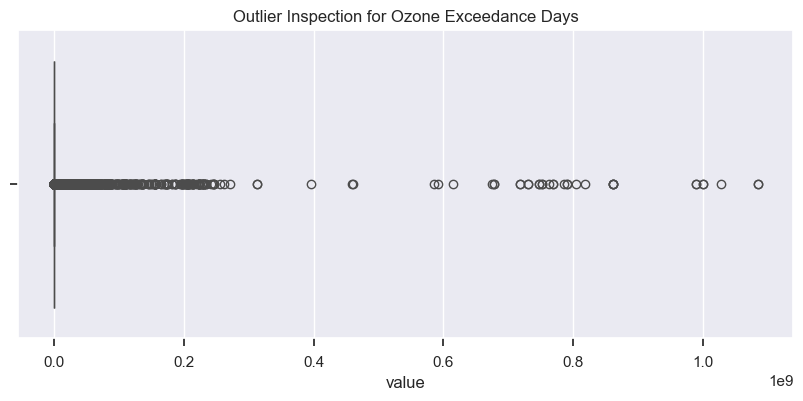

In [65]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["value"])
plt.title("Outlier Inspection for Ozone Exceedance Days")
plt.show()

Outliers are retained at this stage as they may correspond to extreme pollution events,
which are critical for public health risk modeling.


In [66]:
df = df.sort_values(["state_fips", "county_fips", "year"])

In [67]:
df["value_lag_1"] = df.groupby(
    ["state_fips", "county_fips"]
)["value"].shift(1)

df["value_lag_3"] = df.groupby(
    ["state_fips", "county_fips"]
)["value"].shift(3)


In [68]:
df["rolling_mean_3"] = (
    df
    .groupby(["state_fips", "county_fips"])["value"]
    .transform(lambda x: x.rolling(3).mean())
)


In [69]:
df["year_norm"] = df["year"] - df["year"].min()


In [70]:
df["high_risk"] = (df["value"] > df["value"].quantile(0.75)).astype(int)


A binary high-risk indicator is introduced to enable classification-based
risk modeling and early warning systems.


In [71]:
df.head(10)


,state_fips,state,county_fips,county,year,measure_id,measure_name,value,data_origin,monitor_only,value_missing,value_lag_1,value_lag_3,rolling_mean_3,year_norm,high_risk
47646,1,Alabama,1001,Autauga,2001,292,Number of days with maximum 8-hour average ozo...,3.000000,Monitor & Modeled,False,0,NaN,NaN,NaN,2,0
81838,1,Alabama,1001,Autauga,2001,293,Number of person-days with maximum 8-hour aver...,134667.000000,Monitor & Modeled,False,0,3.000000,NaN,NaN,2,1
116094,1,Alabama,1001,Autauga,2001,294,Percent of days with PM2.5 levels over the Nat...,0.000000,Monitor & Modeled,False,0,134667.000000,NaN,44890.000000,2,0
150236,1,Alabama,1001,Autauga,2001,295,Number of person-days with PM2.5 over the Nati...,0.000000,Monitor & Modeled,False,0,0.000000,3.000000,44889.000000,2,0
184435,1,Alabama,1001,Autauga,2001,296,Annual average ambient concentrations of PM 2....,13.186807,Monitor & Modeled,False,0,0.000000,134667.000000,4.395602,2,0
47647,1,Alabama,1001,Autauga,2002,292,Number of days with maximum 8-hour average ozo...,6.000000,Monitor & Modeled,False,0,13.186807,0.000000,6.395602,3,0
81839,1,Alabama,1001,Autauga,2002,293,Number of person-days with maximum 8-hour aver...,275454.000000,Monitor & Modeled,False,0,6.000000,0.000000,91824.395602,3,1
116095,1,Alabama,1001,Autauga,2002,294,Percent of days with PM2.5 levels over the Nat...,0.273973,Monitor & Modeled,False,0,275454.000000,13.186807,91820.091324,3,0
150237,1,Alabama,1001,Autauga,2002,295,Number of person-days with PM2.5 over the Nati...,45909.000000,Monitor & Modeled,False,0,0.273973,6.000000,107121.091324,3,1
184436,1,Alabama,1001,Autauga,2002,296,Annual average ambient concentrations of PM 2....,12.490668,Monitor & Modeled,False,0,45909.000000,275454.000000,15307.254880,3,0


In [72]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
state_fips,218635.0,30.228980,1.513935e+01,1.0,18.000000,29.000000,45.000000,5.600000e+01
county_fips,218635.0,30328.039536,1.515717e+04,1001.0,18146.000000,29189.000000,45021.000000,5.604500e+04
year,218635.0,2005.997777,3.432221e+00,1999.0,2003.000000,2006.000000,2009.000000,2.013000e+03
measure_id,218635.0,248.436979,8.633312e+01,83.0,292.000000,293.000000,295.000000,2.960000e+02
value,218635.0,649964.911851,1.160826e+07,0.0,0.000000,2.000000,13.941047,1.084153e+09
value_missing,218635.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000e+00
value_lag_1,215515.0,658904.626603,1.169153e+07,0.0,0.000000,2.000000,14.000000,1.084153e+09
value_lag_3,209277.0,674994.027897,1.186153e+07,0.0,0.000000,2.479339,14.382359,1.084153e+09
rolling_mean_3,212396.0,659084.577299,7.465239e+06,0.0,2.726896,5834.388173,110850.373157,5.726489e+08
year_norm,218635.0,6.997777,3.432221e+00,0.0,4.000000,7.000000,10.000000,1.400000e+01


In [73]:
OUTPUT_PATH = "../data/processed/air_quality_data_processed.csv"
df.to_csv(OUTPUT_PATH, index=False)

The processed dataset is saved and will serve as the foundation for
all downstream modeling and analysis notebooks.
